# Model Training

## Objective

Develop and compare machine learning models for 24-hour-ahead appliance energy consumption forecasting.

The model will use only information that would realistically be available at the time of forecasting.

## Forecasting objective

Given historical appliance energy consumption and calendar information, predict appliance energy consumption for the next 24 hours.

## Modeling workflow

1. Load the engineered dataset
2. Define the target and predictor variables
3. Create chronological train, validation, and test sets
4. Establish a baseline model
5. Train candidate ML models
6. Compare validation performance
7. Select the best-performing model
8. Evaluate the selected model on the untouched test set

## Important rule

The data must remain in chronological order.

Random train-test splitting is not used because it can allow information from the future to influence model development.

In [2]:
import pandas as pd
import numpy as np

In [3]:
engineered_df = pd.read_csv(
    "D:/Energy_Forecasting/data/processed/engineered_energy_data.csv",
    parse_dates=["date"]
)

In [4]:
engineered_df = engineered_df.set_index("date")

In [5]:
print("Shape:", engineered_df.shape)
print("First timestamp:", engineered_df.index.min())
print("Last timestamp:", engineered_df.index.max())

Shape: (3121, 37)
First timestamp: 2016-01-18 17:00:00
Last timestamp: 2016-05-27 17:00:00


In [7]:
engineered_df.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,day_of_week,is_weekend,lag_1,lag_2,lag_3,lag_24,lag_48,lag_168,rolling_mean_3,rolling_mean_6
date,,,,,,,,,,,,,,,,,,,,,
2016-01-18 17:00:00,210,0,19.172222,41.175556,17.962222,41.530000,19.500000,40.693889,18.616667,38.084722,...,0,0,280.0,200.0,250.0,2730.0,1590.0,330.0,243.333333,246.666667
2016-01-18 18:00:00,1800,50,19.100000,41.075556,17.812222,41.527778,19.357222,40.324444,18.457222,38.157222,...,0,0,210.0,280.0,200.0,1610.0,2840.0,1060.0,230.000000,236.666667
2016-01-18 19:00:00,1170,50,19.574444,42.057778,18.263750,42.203889,19.488889,40.265556,18.317778,38.393333,...,0,0,1800.0,210.0,280.0,610.0,2350.0,1040.0,763.333333,496.666667
2016-01-18 20:00:00,3350,60,20.258611,41.407083,19.100556,42.037778,20.196667,43.094444,18.611667,38.590972,...,0,0,1170.0,1800.0,210.0,660.0,710.0,750.0,1060.000000,651.666667
2016-01-18 21:00:00,2070,70,20.642222,40.164444,19.583788,40.143586,21.028889,45.406667,21.140000,37.362222,...,0,0,3350.0,1170.0,1800.0,780.0,720.0,620.0,2106.666667,1168.333333


In [8]:
engineered_df.tail()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,day_of_week,is_weekend,lag_1,lag_2,lag_3,lag_24,lag_48,lag_168,rolling_mean_3,rolling_mean_6
date,,,,,,,,,,,,,,,,,,,,,
2016-05-27 13:00:00,1590,0,25.217222,47.828333,26.571429,40.840762,28.352778,41.990000,24.538889,45.402778,...,4,0,1110.0,1860.0,1510.0,450.0,430.0,370.0,1493.333333,1240.000000
2016-05-27 14:00:00,610,10,25.544444,46.638889,26.421369,41.205054,28.397778,41.160000,24.666667,45.883889,...,4,0,1590.0,1110.0,1860.0,410.0,480.0,360.0,1520.000000,1393.333333
2016-05-27 15:00:00,460,0,25.500000,45.677639,26.154762,41.041238,28.240000,40.306667,24.694444,45.270000,...,4,0,610.0,1590.0,1110.0,370.0,480.0,280.0,1103.333333,1365.000000
2016-05-27 16:00:00,810,0,25.487778,46.250000,26.000000,41.736190,27.953333,40.607778,24.700000,45.476667,...,4,0,460.0,610.0,1590.0,2970.0,1390.0,290.0,886.666667,1190.000000
2016-05-27 17:00:00,1080,20,25.533333,46.783333,25.772190,42.495476,27.164444,41.247778,24.700000,45.658889,...,4,0,810.0,460.0,610.0,2640.0,710.0,450.0,626.666667,1073.333333


In [10]:
print(
    "Total missing values:",
    engineered_df.isnull().sum().sum()
)

Total missing values: 0


In [9]:
print(
    "Chronologically ordered:",
    engineered_df.index.is_monotonic_increasing
)

Chronologically ordered: True


In [12]:
target = "Appliances"
print("Target:", target)

Target: Appliances


In [13]:
feature_columns = [
    "hour",
    "day_of_week",
    "is_weekend",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_24",
    "lag_48",
    "lag_168",
    "rolling_mean_3",
    "rolling_mean_6"
]

In [14]:
X = engineered_df[feature_columns]
y = engineered_df[target]

In [15]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3121, 11)
y shape: (3121,)


In [16]:
print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)


Features:
['hour', 'day_of_week', 'is_weekend', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_48', 'lag_168', 'rolling_mean_3', 'rolling_mean_6']

Target:
Appliances


In [17]:
n = len(engineered_df)

train_end = int(n * 0.70)
validation_end = int(n * 0.85)

print("Total observations:", n)
print("Training observations:", train_end)
print("Validation observations:", validation_end - train_end)
print("Test observations:", n - validation_end)

Total observations: 3121
Training observations: 2184
Validation observations: 468
Test observations: 469


In [18]:
X_train = X.iloc[:train_end].copy()
X_val = X.iloc[train_end:validation_end].copy()
X_test = X.iloc[validation_end:].copy()

y_train = y.iloc[:train_end].copy()
y_val = y.iloc[train_end:validation_end].copy()
y_test = y.iloc[validation_end:].copy()

In [19]:
print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:  ", y_val.shape)
print("y_test: ", y_test.shape)

X_train: (2184, 11)
X_val:   (468, 11)
X_test:  (469, 11)
y_train: (2184,)
y_val:   (468,)
y_test:  (469,)


In [20]:
print("TRAIN")
print("Start:", X_train.index.min())
print("End:  ", X_train.index.max())

print("\nVALIDATION")
print("Start:", X_val.index.min())
print("End:  ", X_val.index.max())

print("\nTEST")
print("Start:", X_test.index.min())
print("End:  ", X_test.index.max())

TRAIN
Start: 2016-01-18 17:00:00
End:   2016-04-18 16:00:00

VALIDATION
Start: 2016-04-18 17:00:00
End:   2016-05-08 04:00:00

TEST
Start: 2016-05-08 05:00:00
End:   2016-05-27 17:00:00


## Baseline Forecasting

Before training machine learning models, simple forecasting methods are established as
benchmarks.

The ML models must outperform these baselines to demonstrate that they are learning
useful patterns from the historical data.

Three baselines are considered:

1. Previous-hour baseline
2. Previous-day baseline
3. Historical hourly-profile baseline

The baselines will be evaluated using the validation period.

In [ ]:
#Baseline 1 - Previous-hour consumption
y_val_pred_lag1 = engineered_df[target].shift(1).loc[y_val.index]

In [22]:
print(y_val_pred_lag1.head())

date
2016-04-18 17:00:00     420.0
2016-04-18 18:00:00    1580.0
2016-04-18 19:00:00     790.0
2016-04-18 20:00:00     700.0
2016-04-18 21:00:00     750.0
Name: Appliances, dtype: float64


In [23]:
#Baseline 2 - Previous-day consumption
y_val_pred_lag24 = engineered_df[target].shift(24).loc[y_val.index]


In [24]:
print(y_val_pred_lag24.head())

date
2016-04-18 17:00:00    1430.0
2016-04-18 18:00:00     730.0
2016-04-18 19:00:00     740.0
2016-04-18 20:00:00     540.0
2016-04-18 21:00:00     470.0
Name: Appliances, dtype: float64


In [25]:
#Baseline 3 - Historical hourly profile
hourly_baseline = (
    engineered_df.loc[y_train.index]
    .groupby("hour")["Appliances"]
    .mean()
)

hourly_baseline

hour
0      312.417582
1      295.934066
2      286.703297
3      282.747253
4      287.032967
5      291.648352
6      328.351648
7      384.835165
8      601.648352
9      660.549451
10     755.604396
11     819.780220
12     758.901099
13     802.087912
14     689.560440
15     678.461538
16     714.285714
17     837.032967
18    1204.725275
19     904.945055
20     791.978022
21     610.989011
22     409.120879
23     340.549451
Name: Appliances, dtype: float64

In [27]:
y_val_pred_hourly = X_val["hour"].map(hourly_baseline)
print(y_val_pred_hourly.head())

date
2016-04-18 17:00:00     837.032967
2016-04-18 18:00:00    1204.725275
2016-04-18 19:00:00     904.945055
2016-04-18 20:00:00     791.978022
2016-04-18 21:00:00     610.989011
Name: hour, dtype: float64


In [28]:
#Verify the baseline predictions
print("Lag-1 missing:", y_val_pred_lag1.isna().sum())
print("Lag-24 missing:", y_val_pred_lag24.isna().sum())
print("Hourly baseline missing:", y_val_pred_hourly.isna().sum())

Lag-1 missing: 0
Lag-24 missing: 0
Hourly baseline missing: 0


In [30]:
#Evaluate the baselines
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [31]:
#previous hour
lag1_mae = mean_absolute_error(
    y_val,
    y_val_pred_lag1
)

lag1_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        y_val_pred_lag1
    )
)

In [ ]:
#previous day
lag24_mae = mean_absolute_error(
    y_val,
    y_val_pred_lag24
)

lag24_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        y_val_pred_lag24
    )
)

In [33]:
#hourly profile 
hourly_mae = mean_absolute_error(
    y_val,
    y_val_pred_hourly
)

hourly_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        y_val_pred_hourly
    )
)

In [34]:
baseline_results = pd.DataFrame({
    "Model": [
        "Previous Hour",
        "Previous Day",
        "Hourly Profile"
    ],
    "MAE": [
        lag1_mae,
        lag24_mae,
        hourly_mae
    ],
    "RMSE": [
        lag1_rmse,
        lag24_rmse,
        hourly_rmse
    ]
})

baseline_results

,Model,MAE,RMSE
0,Previous Hour,217.136752,394.277441
1,Previous Day,245.619658,460.779023
2,Hourly Profile,244.350286,371.610770


In [35]:
baseline_results.sort_values("MAE")

,Model,MAE,RMSE
0,Previous Hour,217.136752,394.277441
2,Hourly Profile,244.350286,371.610770
1,Previous Day,245.619658,460.779023


## 24-Hour Forecasting Baseline Evaluation

The final application will generate a forecast for the next 24 hours.

Therefore, one-step forecasting performance alone is not sufficient to evaluate the forecasting system.

The baseline methods are evaluated over multiple 24-hour forecasting windows within the validation period.

For each forecasting origin:

1. Only information available up to the forecasting origin is used.
2. The next 24 hours are predicted.
3. The predictions are compared with the actual 24-hour consumption.
4. The process is repeated for multiple forecasting origins.

This provides a more realistic evaluation of the final 24-hour forecasting objective.

In [36]:
validation_start = y_val.index.min()
validation_end = y_val.index.max()

print("Validation start:", validation_start)
print("Validation end:", validation_end)

Validation start: 2016-04-18 17:00:00
Validation end: 2016-05-08 04:00:00


In [37]:
validation_hours = len(y_val)

n_forecast_windows = validation_hours // 24

print("Validation observations:", validation_hours)
print("Complete 24-hour windows:", n_forecast_windows)

Validation observations: 468
Complete 24-hour windows: 19


In [38]:
forecast_origins = [
    y_val.index[i * 24]
    for i in range(n_forecast_windows)
]

print("Number of forecast origins:", len(forecast_origins))
print("First origin:", forecast_origins[0])
print("Last origin:", forecast_origins[-1])

Number of forecast origins: 19
First origin: 2016-04-18 17:00:00
Last origin: 2016-05-06 17:00:00


In [39]:
def recursive_previous_hour(history, horizon=24):
    """
    Recursive previous-hour forecasting.

    The forecast for the next hour is the latest known value.
    Each prediction is then used as the latest value for the
    following forecast step.
    """
    
    last_value = history.iloc[-1]
    
    predictions = []
    
    for _ in range(horizon):
        predictions.append(last_value)
    
    return np.array(predictions)

In [40]:
previous_hour_predictions = []
previous_hour_actuals = []

for origin in forecast_origins:
    
    history = engineered_df.loc[
        :origin,
        target
    ]
    
    future_index = pd.date_range(
        start=origin + pd.Timedelta(hours=1),
        periods=24,
        freq="h"
    )
    
    actual = engineered_df.loc[
        future_index,
        target
    ]
    
    prediction = recursive_previous_hour(
        history,
        horizon=24
    )
    
    previous_hour_predictions.extend(prediction)
    previous_hour_actuals.extend(actual.values)

In [41]:
previous_hour_predictions = np.array(
    previous_hour_predictions
)

previous_hour_actuals = np.array(
    previous_hour_actuals
)

In [42]:
print(
    "Predictions:",
    len(previous_hour_predictions)
)

print(
    "Actuals:",
    len(previous_hour_actuals)
)

Predictions: 456
Actuals: 456


In [43]:
#Calculate the recursive baseline performance
previous_hour_24h_mae = mean_absolute_error(
    previous_hour_actuals,
    previous_hour_predictions
)

previous_hour_24h_rmse = np.sqrt(
    mean_squared_error(
        previous_hour_actuals,
        previous_hour_predictions
    )
)

print("Previous Hour — 24H MAE:", previous_hour_24h_mae)
print("Previous Hour — 24H RMSE:", previous_hour_24h_rmse)

Previous Hour — 24H MAE: 798.6842105263158
Previous Hour — 24H RMSE: 934.3958551037605


In [44]:
print("First 24 actual values:")
print(previous_hour_actuals[:24])

print("\nFirst 24 predictions:")
print(previous_hour_predictions[:24])

First 24 actual values:
[ 790  700  750  370  250  310  320  230  320  310  300  670  470  800
  290  320  230  310  310  270  290  300  310 1490]

First 24 predictions:
[1580 1580 1580 1580 1580 1580 1580 1580 1580 1580 1580 1580 1580 1580
 1580 1580 1580 1580 1580 1580 1580 1580 1580 1580]


In [50]:
def previous_day_forecast(history, future_index, target="Appliances"):
    """
    Forecast each future hour using the consumption
    from exactly 24 hours earlier.
    """
    
    predictions = []
    
    for timestamp in future_index:
        
        previous_day = timestamp - pd.Timedelta(hours=24)
        
        prediction = history.loc[previous_day, target]
        
        predictions.append(prediction)
    
    return np.array(predictions)

In [51]:
previous_day_predictions = []
previous_day_actuals = []

for origin in forecast_origins:
    
    history = engineered_df.loc[:origin]
    
    future_index = pd.date_range(
        start=origin + pd.Timedelta(hours=1),
        periods=24,
        freq="h"
    )
    
    actual = engineered_df.loc[
        future_index,
        target
    ]
    
    prediction = previous_day_forecast(
        history,
        future_index,
        target
    )
    
    previous_day_predictions.extend(prediction)
    previous_day_actuals.extend(actual.values)

In [52]:
previous_day_predictions = np.array(
    previous_day_predictions
)

previous_day_actuals = np.array(
    previous_day_actuals
)

In [53]:
print("Predictions shape:", previous_day_predictions.shape)
print("Actuals shape:", previous_day_actuals.shape)

Predictions shape: (456,)
Actuals shape: (456,)


In [54]:
previous_day_24h_mae = mean_absolute_error(
    previous_day_actuals,
    previous_day_predictions
)

previous_day_24h_rmse = np.sqrt(
    mean_squared_error(
        previous_day_actuals,
        previous_day_predictions
    )
)

print("Previous Day — 24H MAE:", previous_day_24h_mae)
print("Previous Day — 24H RMSE:", previous_day_24h_rmse)

Previous Day — 24H MAE: 249.2982456140351
Previous Day — 24H RMSE: 465.6461272140827


In [55]:
def hourly_profile_forecast(
    hourly_profile,
    future_index
):
    """
    Forecast future consumption using the
    historical average for each hour of day.
    """
    
    predictions = future_index.hour.map(
        hourly_profile
    )
    
    return predictions.to_numpy()

In [56]:
hourly_profile_predictions = []
hourly_profile_actuals = []

for origin in forecast_origins:
    
    future_index = pd.date_range(
        start=origin + pd.Timedelta(hours=1),
        periods=24,
        freq="h"
    )
    
    actual = engineered_df.loc[
        future_index,
        target
    ]
    
    prediction = hourly_profile_forecast(
        hourly_baseline,
        future_index
    )
    
    hourly_profile_predictions.extend(prediction)
    hourly_profile_actuals.extend(actual.values)

In [57]:
hourly_profile_predictions = np.array(
    hourly_profile_predictions
)

hourly_profile_actuals = np.array(
    hourly_profile_actuals
)

In [58]:
print(
    "Predictions shape:",
    hourly_profile_predictions.shape
)

print(
    "Actuals shape:",
    hourly_profile_actuals.shape
)

Predictions shape: (456,)
Actuals shape: (456,)


In [60]:
hourly_profile_24h_mae = mean_absolute_error(
    hourly_profile_actuals,
    hourly_profile_predictions
)

hourly_profile_24h_rmse = np.sqrt(
    mean_squared_error(
        hourly_profile_actuals,
        hourly_profile_predictions
    )
)

print(
    "Hourly Profile - 24H MAE:",
    hourly_profile_24h_mae
)

print(
    "Hourly Profile - 24H RMSE:",
    hourly_profile_24h_rmse
)

Hourly Profile - 24H MAE: 245.95382687487955
Hourly Profile - 24H RMSE: 373.5466441116492


In [61]:
recursive_baseline_results = pd.DataFrame({
    "Model": [
        "Previous Hour",
        "Previous Day",
        "Hourly Profile"
    ],
    "MAE": [
        previous_hour_24h_mae,
        previous_day_24h_mae,
        hourly_profile_24h_mae
    ],
    "RMSE": [
        previous_hour_24h_rmse,
        previous_day_24h_rmse,
        hourly_profile_24h_rmse
    ]
})

recursive_baseline_results = recursive_baseline_results.sort_values(
    "MAE"
).reset_index(drop=True)

recursive_baseline_results

,Model,MAE,RMSE
0,Hourly Profile,245.953827,373.546644
1,Previous Day,249.298246,465.646127
2,Previous Hour,798.684211,934.395855


## Machine Learning Model - Random Forest Regression

A Random Forest Regressor is selected as the first machine learning model.

The model can capture nonlinear relationships between time-based features,
historical consumption features, and the target energy consumption.

The model will initially be trained using the training set and evaluated on
the validation set.

For the final forecasting application, predictions will be generated recursively
for the next 24 hours.

In [62]:
from sklearn.ensemble import RandomForestRegressor

In [63]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("Features:")
print(X_train.columns.tolist())

X_train: (2184, 11)
y_train: (2184,)
X_val: (468, 11)
y_val: (468,)
Features:
['hour', 'day_of_week', 'is_weekend', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_48', 'lag_168', 'rolling_mean_3', 'rolling_mean_6']


In [64]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    max_features="sqrt"
)

In [65]:
rf_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0


In [66]:
y_val_pred_rf = rf_model.predict(X_val)

In [67]:
print("Prediction shape:", y_val_pred_rf.shape)
print("Actual shape:", y_val.shape)

Prediction shape: (468,)
Actual shape: (468,)


In [68]:
rf_val_mae = mean_absolute_error(
    y_val,
    y_val_pred_rf
)

rf_val_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        y_val_pred_rf
    )
)

print("Random Forest — One-step Validation MAE:", rf_val_mae)
print("Random Forest — One-step Validation RMSE:", rf_val_rmse)

Random Forest — One-step Validation MAE: 184.16645299145299
Random Forest — One-step Validation RMSE: 310.81662211900783


In [69]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(
    ascending=False
)

feature_importance

lag_1             0.218952
rolling_mean_3    0.145133
lag_2             0.113819
hour              0.103337
lag_24            0.085862
lag_168           0.084550
rolling_mean_6    0.079977
lag_48            0.066099
lag_3             0.066029
day_of_week       0.030282
is_weekend        0.005960
dtype: float64

## Recursive 24-Hour Forecasting

The Random Forest model is evaluated using recursive forecasting.

Only observations available at the forecast origin are used initially.
After each prediction, the predicted value is added to a temporary history
and is used to construct the lag and rolling features required for the next
forecast step.

Actual future `Appliances` values are never used during forecasting.

In [70]:
def create_recursive_features(history, timestamp):
    """
    Create the feature vector required to forecast one future timestamp.
    
    The history contains only observations that are available at the
    current forecasting step.
    """
    
    features = {
        "hour": timestamp.hour,
        "day_of_week": timestamp.dayofweek,
        "is_weekend": int(timestamp.dayofweek >= 5),
        
        "lag_1": history.loc[
            timestamp - pd.Timedelta(hours=1)
        ],
        
        "lag_2": history.loc[
            timestamp - pd.Timedelta(hours=2)
        ],
        
        "lag_3": history.loc[
            timestamp - pd.Timedelta(hours=3)
        ],
        
        "lag_24": history.loc[
            timestamp - pd.Timedelta(hours=24)
        ],
        
        "lag_48": history.loc[
            timestamp - pd.Timedelta(hours=48)
        ],
        
        "lag_168": history.loc[
            timestamp - pd.Timedelta(hours=168)
        ],
        
        "rolling_mean_3": history.iloc[-3:].mean(),
        
        "rolling_mean_6": history.iloc[-6:].mean()
    }
    
    return pd.DataFrame([features], index=[timestamp])

In [71]:
def recursive_24h_forecast(
    model,
    history,
    start_timestamp,
    horizon=24
):
    """
    Generate a recursive multi-step forecast.
    
    Parameters
    ----------
    model : trained forecasting model
    history : pandas Series
        Historical Appliances values indexed by timestamp.
    start_timestamp : pandas.Timestamp
        Last timestamp for which actual data is available.
    horizon : int
        Number of future hours to forecast.
        
    Returns
    -------
    pandas.Series
        Forecasted Appliances values.
    """
    
    # Create a copy so the original history is not modified
    temp_history = history.copy()
    
    predictions = []
    
    current_timestamp = start_timestamp
    
    for step in range(1, horizon + 1):
        
        future_timestamp = (
            current_timestamp +
            pd.Timedelta(hours=1)
        )
        
        # Create features using only currently available history
        X_future = create_recursive_features(
            temp_history,
            future_timestamp
        )
        
        # Keep exactly the same feature order used during training
        X_future = X_future[X_train.columns]
        
        # Predict the next hour
        prediction = model.predict(X_future)[0]
        
        # Store prediction
        predictions.append(prediction)
        
        # Add prediction to temporary history
        temp_history.loc[future_timestamp] = prediction
        
        # Move forecast origin forward
        current_timestamp = future_timestamp
    
    future_index = pd.date_range(
        start=start_timestamp + pd.Timedelta(hours=1),
        periods=horizon,
        freq="h"
    )
    
    return pd.Series(
        predictions,
        index=future_index,
        name="prediction"
    )

In [72]:
test_origin = forecast_origins[0]

history = engineered_df.loc[
    :test_origin,
    target
]

recursive_test_prediction = recursive_24h_forecast(
    model=rf_model,
    history=history,
    start_timestamp=test_origin,
    horizon=24
)

recursive_test_prediction

2016-04-18 18:00:00     937.566667
2016-04-18 19:00:00     947.266667
2016-04-18 20:00:00     809.966667
2016-04-18 21:00:00     587.100000
2016-04-18 22:00:00     417.900000
2016-04-18 23:00:00     359.966667
2016-04-19 00:00:00     340.233333
2016-04-19 01:00:00     324.366667
2016-04-19 02:00:00     311.500000
2016-04-19 03:00:00     297.233333
2016-04-19 04:00:00     294.866667
2016-04-19 05:00:00     304.166667
2016-04-19 06:00:00     336.933333
2016-04-19 07:00:00     394.866667
2016-04-19 08:00:00     543.733333
2016-04-19 09:00:00     540.300000
2016-04-19 10:00:00     640.366667
2016-04-19 11:00:00     655.133333
2016-04-19 12:00:00     641.533333
2016-04-19 13:00:00     687.866667
2016-04-19 14:00:00     646.266667
2016-04-19 15:00:00     802.166667
2016-04-19 16:00:00     762.466667
2016-04-19 17:00:00    1243.833333
Freq: h, Name: prediction, dtype: float64

In [73]:
print(
    "Number of predictions:",
    len(recursive_test_prediction)
)

print(
    "First timestamp:",
    recursive_test_prediction.index[0]
)

print(
    "Last timestamp:",
    recursive_test_prediction.index[-1]
)

Number of predictions: 24
First timestamp: 2016-04-18 18:00:00
Last timestamp: 2016-04-19 17:00:00


In [74]:
print(recursive_test_prediction)

2016-04-18 18:00:00     937.566667
2016-04-18 19:00:00     947.266667
2016-04-18 20:00:00     809.966667
2016-04-18 21:00:00     587.100000
2016-04-18 22:00:00     417.900000
2016-04-18 23:00:00     359.966667
2016-04-19 00:00:00     340.233333
2016-04-19 01:00:00     324.366667
2016-04-19 02:00:00     311.500000
2016-04-19 03:00:00     297.233333
2016-04-19 04:00:00     294.866667
2016-04-19 05:00:00     304.166667
2016-04-19 06:00:00     336.933333
2016-04-19 07:00:00     394.866667
2016-04-19 08:00:00     543.733333
2016-04-19 09:00:00     540.300000
2016-04-19 10:00:00     640.366667
2016-04-19 11:00:00     655.133333
2016-04-19 12:00:00     641.533333
2016-04-19 13:00:00     687.866667
2016-04-19 14:00:00     646.266667
2016-04-19 15:00:00     802.166667
2016-04-19 16:00:00     762.466667
2016-04-19 17:00:00    1243.833333
Freq: h, Name: prediction, dtype: float64


In [75]:
actual_test = engineered_df.loc[
    recursive_test_prediction.index,
    target
]

comparison = pd.DataFrame({
    "Actual": actual_test,
    "Prediction": recursive_test_prediction
})

comparison

,Actual,Prediction
2016-04-18 18:00:00,790,937.566667
2016-04-18 19:00:00,700,947.266667
2016-04-18 20:00:00,750,809.966667
2016-04-18 21:00:00,370,587.100000
2016-04-18 22:00:00,250,417.900000
2016-04-18 23:00:00,310,359.966667
2016-04-19 00:00:00,320,340.233333
2016-04-19 01:00:00,230,324.366667
2016-04-19 02:00:00,320,311.500000
2016-04-19 03:00:00,310,297.233333


In [76]:
print(
    "History last timestamp:",
    history.index[-1]
)

print(
    "Forecast first timestamp:",
    recursive_test_prediction.index[0]
)

History last timestamp: 2016-04-18 17:00:00
Forecast first timestamp: 2016-04-18 18:00:00


In [77]:
rf_recursive_predictions = []
rf_recursive_actuals = []

for origin in forecast_origins:
    
    history = engineered_df.loc[
        :origin,
        target
    ]
    
    forecast = recursive_24h_forecast(
        model=rf_model,
        history=history,
        start_timestamp=origin,
        horizon=24
    )
    
    actual = engineered_df.loc[
        forecast.index,
        target
    ]
    
    rf_recursive_predictions.extend(
        forecast.values
    )
    
    rf_recursive_actuals.extend(
        actual.values
    )

In [78]:
rf_recursive_predictions = np.array(
    rf_recursive_predictions
)

rf_recursive_actuals = np.array(
    rf_recursive_actuals
)

In [79]:
print(
    "Predictions shape:",
    rf_recursive_predictions.shape
)

print(
    "Actuals shape:",
    rf_recursive_actuals.shape
)

Predictions shape: (456,)
Actuals shape: (456,)


In [80]:
rf_24h_mae = mean_absolute_error(
    rf_recursive_actuals,
    rf_recursive_predictions
)

rf_24h_rmse = np.sqrt(
    mean_squared_error(
        rf_recursive_actuals,
        rf_recursive_predictions
    )
)

print(
    "Random Forest — 24H Recursive MAE:",
    rf_24h_mae
)

print(
    "Random Forest — 24H Recursive RMSE:",
    rf_24h_rmse
)

Random Forest — 24H Recursive MAE: 245.28033625730993
Random Forest — 24H Recursive RMSE: 361.52661825799817


In [81]:
rf_results = pd.DataFrame({
    "Actual": rf_recursive_actuals,
    "Prediction": rf_recursive_predictions
})

rf_results["Error"] = (
    rf_results["Actual"]
    - rf_results["Prediction"]
)

rf_results["Absolute_Error"] = (
    rf_results["Error"]
    .abs()
)

rf_results["Squared_Error"] = (
    rf_results["Error"] ** 2
)

rf_results.head()

,Actual,Prediction,Error,Absolute_Error,Squared_Error
0,790,937.566667,-147.566667,147.566667,21775.921111
1,700,947.266667,-247.266667,247.266667,61140.804444
2,750,809.966667,-59.966667,59.966667,3596.001111
3,370,587.100000,-217.100000,217.100000,47132.410000
4,250,417.900000,-167.900000,167.900000,28190.410000


In [82]:
print("Rows:", len(rf_results))
print("Columns:", rf_results.columns.tolist())

Rows: 456
Columns: ['Actual', 'Prediction', 'Error', 'Absolute_Error', 'Squared_Error']


In [84]:
rf_results["forecast_horizon"] = (
    np.tile(
        np.arange(1, 25),
        len(forecast_origins)
    )
)

print(
    rf_results["forecast_horizon"].value_counts()
    .sort_index()
)

forecast_horizon
1     19
2     19
3     19
4     19
5     19
6     19
7     19
8     19
9     19
10    19
11    19
12    19
13    19
14    19
15    19
16    19
17    19
18    19
19    19
20    19
21    19
22    19
23    19
24    19
Name: count, dtype: int64


In [85]:
horizon_mae = (
    rf_results
    .groupby("forecast_horizon")["Absolute_Error"]
    .mean()
)

horizon_mae

forecast_horizon
1     363.707018
2     250.807018
3     157.343860
4     154.157895
5      83.870175
6      58.321053
7      32.080702
8      46.057895
9      33.792982
10     44.422807
11     31.307018
12    136.284211
13    103.398246
14    425.773684
15    327.371930
16    411.303509
17    522.375439
18    353.924561
19    399.400000
20    361.224561
21    345.033333
22    349.224561
23    447.243860
24    448.301754
Name: Absolute_Error, dtype: float64

In [86]:
horizon_rmse = (
    rf_results
    .groupby("forecast_horizon")["Squared_Error"]
    .mean()
    .pow(0.5)
)

horizon_rmse

forecast_horizon
1     474.349773
2     311.230835
3     229.615577
4     170.339088
5     101.350805
6      70.885175
7      42.118763
8      56.974352
9      44.914694
10     52.261713
11     41.504045
12    169.357179
13    126.686381
14    509.337525
15    389.250624
16    511.785020
17    717.101781
18    406.198228
19    507.517798
20    420.789448
21    372.716433
22    406.042834
23    529.958523
24    538.819559
Name: Squared_Error, dtype: float64

## Rebuild the results with the actual timestamps

In [87]:
rf_error_results = []

for origin in forecast_origins:

    history = engineered_df.loc[
        :origin,
        target
    ]

    forecast = recursive_24h_forecast(
        model=rf_model,
        history=history,
        start_timestamp=origin,
        horizon=24
    )

    actual = engineered_df.loc[
        forecast.index,
        target
    ]

    for timestamp in forecast.index:

        prediction = forecast.loc[timestamp]
        actual_value = actual.loc[timestamp]

        rf_error_results.append({
            "date": timestamp,
            "hour": timestamp.hour,
            "actual": actual_value,
            "prediction": prediction,
            "absolute_error": abs(
                actual_value - prediction
            ),
            "squared_error": (
                actual_value - prediction
            ) ** 2
        })

rf_error_results = pd.DataFrame(
    rf_error_results
)

In [88]:
print("Shape:", rf_error_results.shape)
print(rf_error_results.head())

Shape: (456, 6)
                 date  hour  actual  prediction  absolute_error  squared_error
0 2016-04-18 18:00:00    18     790  937.566667      147.566667   21775.921111
1 2016-04-18 19:00:00    19     700  947.266667      247.266667   61140.804444
2 2016-04-18 20:00:00    20     750  809.966667       59.966667    3596.001111
3 2016-04-18 21:00:00    21     370  587.100000      217.100000   47132.410000
4 2016-04-18 22:00:00    22     250  417.900000      167.900000   28190.410000


In [89]:
hourly_error = (
    rf_error_results
    .groupby("hour")["absolute_error"]
    .mean()
)

hourly_error

hour
0      32.080702
1      46.057895
2      33.792982
3      44.422807
4      31.307018
5     136.284211
6     103.398246
7     425.773684
8     327.371930
9     411.303509
10    522.375439
11    353.924561
12    399.400000
13    361.224561
14    345.033333
15    349.224561
16    447.243860
17    448.301754
18    363.707018
19    250.807018
20    157.343860
21    154.157895
22     83.870175
23     58.321053
Name: absolute_error, dtype: float64

In [90]:
hourly_rmse = (
    rf_error_results
    .groupby("hour")["squared_error"]
    .mean()
    .pow(0.5)
)

hourly_rmse

hour
0      42.118763
1      56.974352
2      44.914694
3      52.261713
4      41.504045
5     169.357179
6     126.686381
7     509.337525
8     389.250624
9     511.785020
10    717.101781
11    406.198228
12    507.517798
13    420.789448
14    372.716433
15    406.042834
16    529.958523
17    538.819559
18    474.349773
19    311.230835
20    229.615577
21    170.339088
22    101.350805
23     70.885175
Name: squared_error, dtype: float64

In [93]:
hourly_analysis = pd.DataFrame({
    "Average_Energy": hourly_baseline,
    "RF_MAE": hourly_error,
    "RF_RMSE": hourly_rmse
})

hourly_analysis

,Average_Energy,RF_MAE,RF_RMSE
hour,,,
0,312.417582,32.080702,42.118763
1,295.934066,46.057895,56.974352
2,286.703297,33.792982,44.914694
3,282.747253,44.422807,52.261713
4,287.032967,31.307018,41.504045
5,291.648352,136.284211,169.357179
6,328.351648,103.398246,126.686381
7,384.835165,425.773684,509.337525
8,601.648352,327.371930,389.250624


In [95]:
hourly_analysis.sort_values(
    "RF_MAE",
    ascending=False
)

,Average_Energy,RF_MAE,RF_RMSE
hour,,,
10,755.604396,522.375439,717.101781
17,837.032967,448.301754,538.819559
16,714.285714,447.243860,529.958523
7,384.835165,425.773684,509.337525
9,660.549451,411.303509,511.785020
12,758.901099,399.400000,507.517798
18,1204.725275,363.707018,474.349773
13,802.087912,361.224561,420.789448
11,819.780220,353.924561,406.198228


The recursive forecasting error is influenced more by the time-of-day consumption dynamics than simply by how far into the future we forecast.

In [97]:
from sklearn.ensemble import RandomForestRegressor

In [98]:
rf_candidates = {
    "RF_Default": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    
    "RF_More_Trees": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    
    "RF_Shallow": RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),
    
    "RF_Deep": RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    ),
    
    "RF_Larger_Leaf": RandomForestRegressor(
        n_estimators=200,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    )
}

print("Number of candidate models:", len(rf_candidates))

Number of candidate models: 5


In [99]:
rf_candidate_results = {}

for name, candidate_model in rf_candidates.items():

    print(f"Training {name}...")

    candidate_model.fit(
        X_train,
        y_train
    )

    rf_candidate_results[name] = candidate_model

print("All candidate models trained.")

Training RF_Default...
Training RF_More_Trees...
Training RF_Shallow...
Training RF_Deep...
Training RF_Larger_Leaf...
All candidate models trained.


In [100]:
rf_tuning_one_step = []

for name, candidate_model in rf_candidate_results.items():

    predictions = candidate_model.predict(X_val)

    mae = mean_absolute_error(
        y_val,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_val,
            predictions
        )
    )

    rf_tuning_one_step.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse
    })

rf_tuning_one_step_df = pd.DataFrame(
    rf_tuning_one_step
)

rf_tuning_one_step_df.sort_values(
    "MAE"
)

,Model,MAE,RMSE
4,RF_Larger_Leaf,182.091572,309.086170
2,RF_Shallow,183.335673,313.864834
1,RF_More_Trees,185.432977,313.800014
3,RF_Deep,186.197574,315.184059
0,RF_Default,188.434615,317.586489


In [102]:
rf_recursive_tuning_results = []

for name, candidate_model in rf_candidate_results.items():

    print(f"Evaluating {name}...")

    predictions = []
    actuals = []

    for origin in forecast_origins:

        history = engineered_df.loc[
            :origin,
            target
        ]

        forecast = recursive_24h_forecast(
            model=candidate_model,
            history=history,
            start_timestamp=origin,
            horizon=24
        )

        actual = engineered_df.loc[
            forecast.index,
            target
        ]

        predictions.extend(
            forecast.values
        )

        actuals.extend(
            actual.values
        )

    predictions = np.array(predictions)
    actuals = np.array(actuals)

    mae = mean_absolute_error(
        actuals,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            actuals,
            predictions
        )
    )

    rf_recursive_tuning_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse
    })

rf_recursive_tuning_df = pd.DataFrame(
    rf_recursive_tuning_results
)

rf_recursive_tuning_df.sort_values(
    "MAE"
)

Evaluating RF_Default...
Evaluating RF_More_Trees...
Evaluating RF_Shallow...
Evaluating RF_Deep...
Evaluating RF_Larger_Leaf...


,Model,MAE,RMSE
2,RF_Shallow,245.567441,367.377106
4,RF_Larger_Leaf,250.506643,369.779433
0,RF_Default,252.657895,371.396711
1,RF_More_Trees,257.080994,377.085403
3,RF_Deep,261.769214,379.491353


In [103]:
print(
    "Number of forecast origins:",
    len(forecast_origins)
)

print(
    "Forecast horizon:",
    24
)

print(
    "Expected predictions:",
    len(forecast_origins) * 24
)

Number of forecast origins: 19
Forecast horizon: 24
Expected predictions: 456


In [104]:
print(rf_model)

RandomForestRegressor(max_features='sqrt', n_estimators=300, n_jobs=-1,
                      random_state=42)


In [105]:
print("Original RF parameters:")
print(rf_model.get_params())

Original RF parameters:
{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 300, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [106]:
rf_original_config = RandomForestRegressor(
    n_estimators=300,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_original_config.fit(
    X_train,
    y_train
)

print(rf_original_config)

RandomForestRegressor(max_features='sqrt', n_estimators=300, n_jobs=-1,
                      random_state=42)


In [107]:
original_check_predictions = rf_original_config.predict(
    X_val
)

original_check_mae = mean_absolute_error(
    y_val,
    original_check_predictions
)

original_check_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        original_check_predictions
    )
)

print(
    "Original configuration — One-step MAE:",
    original_check_mae
)

print(
    "Original configuration — One-step RMSE:",
    original_check_rmse
)

Original configuration — One-step MAE: 184.16645299145299
Original configuration — One-step RMSE: 310.81662211900783


In [108]:
test_start = X_test.index[0]
test_end = X_test.index[-1]

print("Test start:", test_start)
print("Test end:", test_end)

Test start: 2016-05-08 05:00:00
Test end: 2016-05-27 17:00:00


In [109]:
test_forecast_start = engineered_df.index[
    engineered_df.index >= test_start
][0]

test_forecast_end = (
    engineered_df.index[-1]
    - pd.Timedelta(hours=24)
)

print("Test forecast start:", test_forecast_start)
print("Latest possible forecast origin:", test_forecast_end)

Test forecast start: 2016-05-08 05:00:00
Latest possible forecast origin: 2016-05-26 17:00:00


In [110]:
test_forecast_origins = engineered_df.index[
    (engineered_df.index >= test_forecast_start) &
    (engineered_df.index <= test_forecast_end)
]

print("Number of test forecast origins:", len(test_forecast_origins))
print("First origin:", test_forecast_origins[0])
print("Last origin:", test_forecast_origins[-1])

Number of test forecast origins: 445
First origin: 2016-05-08 05:00:00
Last origin: 2016-05-26 17:00:00


In [111]:
print("Number of validation origins:", len(forecast_origins))

print("\nValidation forecast origins:")
print(forecast_origins)

Number of validation origins: 19

Validation forecast origins:
[Timestamp('2016-04-18 17:00:00'), Timestamp('2016-04-19 17:00:00'), Timestamp('2016-04-20 17:00:00'), Timestamp('2016-04-21 17:00:00'), Timestamp('2016-04-22 17:00:00'), Timestamp('2016-04-23 17:00:00'), Timestamp('2016-04-24 17:00:00'), Timestamp('2016-04-25 17:00:00'), Timestamp('2016-04-26 17:00:00'), Timestamp('2016-04-27 17:00:00'), Timestamp('2016-04-28 17:00:00'), Timestamp('2016-04-29 17:00:00'), Timestamp('2016-04-30 17:00:00'), Timestamp('2016-05-01 17:00:00'), Timestamp('2016-05-02 17:00:00'), Timestamp('2016-05-03 17:00:00'), Timestamp('2016-05-04 17:00:00'), Timestamp('2016-05-05 17:00:00'), Timestamp('2016-05-06 17:00:00')]


In [112]:
print("\nDifferences between validation origins:")
print(
    pd.Series(forecast_origins)
    .diff()
    .value_counts()
)


Differences between validation origins:
1 days    18
Name: count, dtype: int64


In [113]:
test_forecast_origins = pd.date_range(
    start=test_forecast_start,
    end=test_forecast_end,
    freq="24h"
)

print("Number of test forecast origins:", len(test_forecast_origins))
print("First origin:", test_forecast_origins[0])
print("Last origin:", test_forecast_origins[-1])

Number of test forecast origins: 19
First origin: 2016-05-08 05:00:00
Last origin: 2016-05-26 05:00:00


In [114]:
test_predictions = []
test_actuals = []

for origin in test_forecast_origins:

    history = engineered_df.loc[
        :origin,
        target
    ]

    forecast = recursive_24h_forecast(
        model=rf_model,
        history=history,
        start_timestamp=origin,
        horizon=24
    )

    actual = engineered_df.loc[
        forecast.index,
        target
    ]

    test_predictions.extend(
        forecast.values
    )

    test_actuals.extend(
        actual.values
    )

test_predictions = np.array(test_predictions)
test_actuals = np.array(test_actuals)

print("Predictions shape:", test_predictions.shape)
print("Actuals shape:", test_actuals.shape)

Predictions shape: (456,)
Actuals shape: (456,)


In [115]:
final_test_mae = mean_absolute_error(
    test_actuals,
    test_predictions
)

final_test_rmse = np.sqrt(
    mean_squared_error(
        test_actuals,
        test_predictions
    )
)

print(
    "Final Test — 24H Recursive MAE:",
    final_test_mae
)

print(
    "Final Test — 24H Recursive RMSE:",
    final_test_rmse
)

Final Test — 24H Recursive MAE: 235.37470760233919
Final Test — 24H Recursive RMSE: 373.1036554557258


In [116]:
test_results = pd.DataFrame({
    "Actual": test_actuals,
    "Prediction": test_predictions
})

test_results["Absolute_Error"] = (
    test_results["Actual"] -
    test_results["Prediction"]
).abs()

test_results["Error"] = (
    test_results["Actual"] -
    test_results["Prediction"]
)

test_results["Squared_Error"] = (
    test_results["Error"] ** 2
)

print("Test results shape:", test_results.shape)

test_results.head()

Test results shape: (456, 5)


,Actual,Prediction,Absolute_Error,Error,Squared_Error
0,300,365.166667,65.166667,-65.166667,4246.694444
1,360,677.133333,317.133333,-317.133333,100573.551111
2,1100,724.333333,375.666667,375.666667,141125.444444
3,860,999.266667,139.266667,-139.266667,19395.204444
4,810,849.500000,39.500000,-39.500000,1560.250000


In [117]:
test_timestamps = []

for origin in test_forecast_origins:

    history = engineered_df.loc[
        :origin,
        target
    ]

    forecast = recursive_24h_forecast(
        model=rf_model,
        history=history,
        start_timestamp=origin,
        horizon=24
    )

    test_timestamps.extend(
        forecast.index
    )

test_results.index = pd.DatetimeIndex(
    test_timestamps
)

test_results.index.name = "date"

test_results.head()

,Actual,Prediction,Absolute_Error,Error,Squared_Error
date,,,,,
2016-05-08 06:00:00,300,365.166667,65.166667,-65.166667,4246.694444
2016-05-08 07:00:00,360,677.133333,317.133333,-317.133333,100573.551111
2016-05-08 08:00:00,1100,724.333333,375.666667,375.666667,141125.444444
2016-05-08 09:00:00,860,999.266667,139.266667,-139.266667,19395.204444
2016-05-08 10:00:00,810,849.500000,39.500000,-39.500000,1560.250000


In [118]:
print("First timestamp:", test_results.index[0])
print("Last timestamp:", test_results.index[-1])
print("Duplicate timestamps:", test_results.index.duplicated().sum())

First timestamp: 2016-05-08 06:00:00
Last timestamp: 2016-05-27 05:00:00
Duplicate timestamps: 0


In [119]:
largest_errors = test_results.sort_values(
    "Absolute_Error",
    ascending=False
)

largest_errors.head(10)

,Actual,Prediction,Absolute_Error,Error,Squared_Error
date,,,,,
2016-05-26 16:00:00,2970,869.133333,2100.866667,2100.866667,4.413641e+06
2016-05-21 11:00:00,2590,772.966667,1817.033333,1817.033333,3.301610e+06
2016-05-26 17:00:00,2640,878.100000,1761.900000,1761.900000,3.104292e+06
2016-05-21 10:00:00,2300,834.233333,1465.766667,1465.766667,2.148472e+06
2016-05-13 08:00:00,2030,593.566667,1436.433333,1436.433333,2.063341e+06
2016-05-21 15:00:00,2170,808.366667,1361.633333,1361.633333,1.854045e+06
2016-05-13 16:00:00,2110,833.100000,1276.900000,1276.900000,1.630474e+06
2016-05-21 13:00:00,2060,850.000000,1210.000000,1210.000000,1.464100e+06
2016-05-13 18:00:00,2090,895.000000,1195.000000,1195.000000,1.428025e+06


In [120]:
print(
    largest_errors[
        [
            "Actual",
            "Prediction",
            "Absolute_Error",
            "Error"
        ]
    ].head(10)
)

                     Actual  Prediction  Absolute_Error        Error
date                                                                
2016-05-26 16:00:00    2970  869.133333     2100.866667  2100.866667
2016-05-21 11:00:00    2590  772.966667     1817.033333  1817.033333
2016-05-26 17:00:00    2640  878.100000     1761.900000  1761.900000
2016-05-21 10:00:00    2300  834.233333     1465.766667  1465.766667
2016-05-13 08:00:00    2030  593.566667     1436.433333  1436.433333
2016-05-21 15:00:00    2170  808.366667     1361.633333  1361.633333
2016-05-13 16:00:00    2110  833.100000     1276.900000  1276.900000
2016-05-21 13:00:00    2060  850.000000     1210.000000  1210.000000
2016-05-13 18:00:00    2090  895.000000     1195.000000  1195.000000
2016-05-13 11:00:00    2130  952.300000     1177.700000  1177.700000


In [121]:
test_results["hour"] = test_results.index.hour

test_hourly_error = (
    test_results
    .groupby("hour")["Absolute_Error"]
    .mean()
)

test_hourly_error

hour
0      31.580702
1      28.294737
2      24.910526
3      26.910526
4      20.931579
5      60.242105
6     122.524561
7     177.835088
8     343.205263
9     355.864912
10    347.591228
11    531.221053
12    388.756140
13    412.594737
14    405.787719
15    354.500000
16    421.708772
17    500.801754
18    344.173684
19    222.552632
20    213.817544
21    167.587719
22     62.124561
23     83.475439
Name: Absolute_Error, dtype: float64

In [122]:
test_hourly_error.sort_values(
    ascending=False
)

hour
11    531.221053
17    500.801754
16    421.708772
13    412.594737
14    405.787719
12    388.756140
9     355.864912
15    354.500000
10    347.591228
18    344.173684
8     343.205263
19    222.552632
20    213.817544
7     177.835088
21    167.587719
6     122.524561
23     83.475439
22     62.124561
5      60.242105
0      31.580702
1      28.294737
3      26.910526
2      24.910526
4      20.931579
Name: Absolute_Error, dtype: float64

In [123]:
test_hourly_bias = (
    test_results
    .groupby("hour")["Error"]
    .mean()
)

test_hourly_bias.sort_values()

hour
18   -156.317544
9    -155.545614
14   -155.149123
15   -150.591228
19   -104.626316
12   -101.566667
13    -90.773684
7     -83.347368
10    -74.798246
21    -64.900000
6     -45.685965
11    -42.150877
22    -30.345614
20    -11.722807
0      -3.763158
5       3.656140
1       3.863158
3       5.882456
2       7.707018
4      11.026316
16     12.912281
23     24.433333
8      32.780702
17    205.563158
Name: Error, dtype: float64

In [124]:
largest_errors = test_results.sort_values(
    "Absolute_Error",
    ascending=False
)

largest_errors.head(10)

,Actual,Prediction,Absolute_Error,Error,Squared_Error,hour
date,,,,,,
2016-05-26 16:00:00,2970,869.133333,2100.866667,2100.866667,4.413641e+06,16
2016-05-21 11:00:00,2590,772.966667,1817.033333,1817.033333,3.301610e+06,11
2016-05-26 17:00:00,2640,878.100000,1761.900000,1761.900000,3.104292e+06,17
2016-05-21 10:00:00,2300,834.233333,1465.766667,1465.766667,2.148472e+06,10
2016-05-13 08:00:00,2030,593.566667,1436.433333,1436.433333,2.063341e+06,8
2016-05-21 15:00:00,2170,808.366667,1361.633333,1361.633333,1.854045e+06,15
2016-05-13 16:00:00,2110,833.100000,1276.900000,1276.900000,1.630474e+06,16
2016-05-21 13:00:00,2060,850.000000,1210.000000,1210.000000,1.464100e+06,13
2016-05-13 18:00:00,2090,895.000000,1195.000000,1195.000000,1.428025e+06,18


In [125]:
test_hourly_error = (
    test_results
    .groupby("hour")["Absolute_Error"]
    .mean()
)

test_hourly_error.sort_values(
    ascending=False
)

hour
11    531.221053
17    500.801754
16    421.708772
13    412.594737
14    405.787719
12    388.756140
9     355.864912
15    354.500000
10    347.591228
18    344.173684
8     343.205263
19    222.552632
20    213.817544
7     177.835088
21    167.587719
6     122.524561
23     83.475439
22     62.124561
5      60.242105
0      31.580702
1      28.294737
3      26.910526
2      24.910526
4      20.931579
Name: Absolute_Error, dtype: float64

In [126]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
)

feature_importance = feature_importance.sort_values(
    ascending=False
)

feature_importance

lag_1             0.218952
rolling_mean_3    0.145133
lag_2             0.113819
hour              0.103337
lag_24            0.085862
lag_168           0.084550
rolling_mean_6    0.079977
lag_48            0.066099
lag_3             0.066029
day_of_week       0.030282
is_weekend        0.005960
dtype: float64

In [127]:
print(
    "Feature importance sum:",
    feature_importance.sum()
)

Feature importance sum: 0.9999999999999999


In [128]:
feature_importance

lag_1             0.218952
rolling_mean_3    0.145133
lag_2             0.113819
hour              0.103337
lag_24            0.085862
lag_168           0.084550
rolling_mean_6    0.079977
lag_48            0.066099
lag_3             0.066029
day_of_week       0.030282
is_weekend        0.005960
dtype: float64

## Residual analysis

In [129]:
residual_summary = test_results["Error"].describe()

residual_summary

count     456.000000
mean      -40.144152
std       371.345110
min     -1009.233333
25%      -238.158333
50%       -57.100000
75%        25.033333
max      2100.866667
Name: Error, dtype: float64

In [130]:
print(
    "Mean residual:",
    test_results["Error"].mean()
)

print(
    "Median residual:",
    test_results["Error"].median()
)

print(
    "Maximum overprediction:",
    test_results["Error"].min()
)

print(
    "Maximum underprediction:",
    test_results["Error"].max()
)

Mean residual: -40.144152046783624
Median residual: -57.10000000000002
Maximum overprediction: -1009.2333333333333
Maximum underprediction: 2100.866666666667


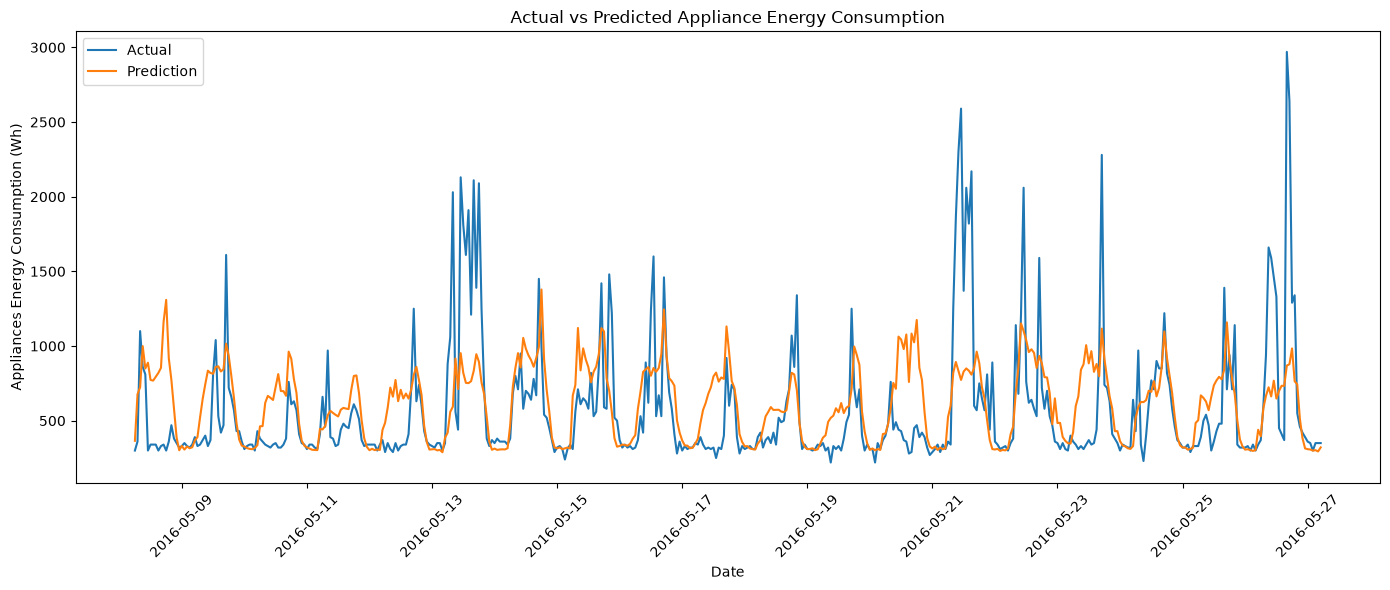

In [131]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    test_results.index,
    test_results["Actual"],
    label="Actual"
)

plt.plot(
    test_results.index,
    test_results["Prediction"],
    label="Prediction"
)

plt.xlabel("Date")
plt.ylabel("Appliances Energy Consumption (Wh)")
plt.title("Actual vs Predicted Appliance Energy Consumption")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

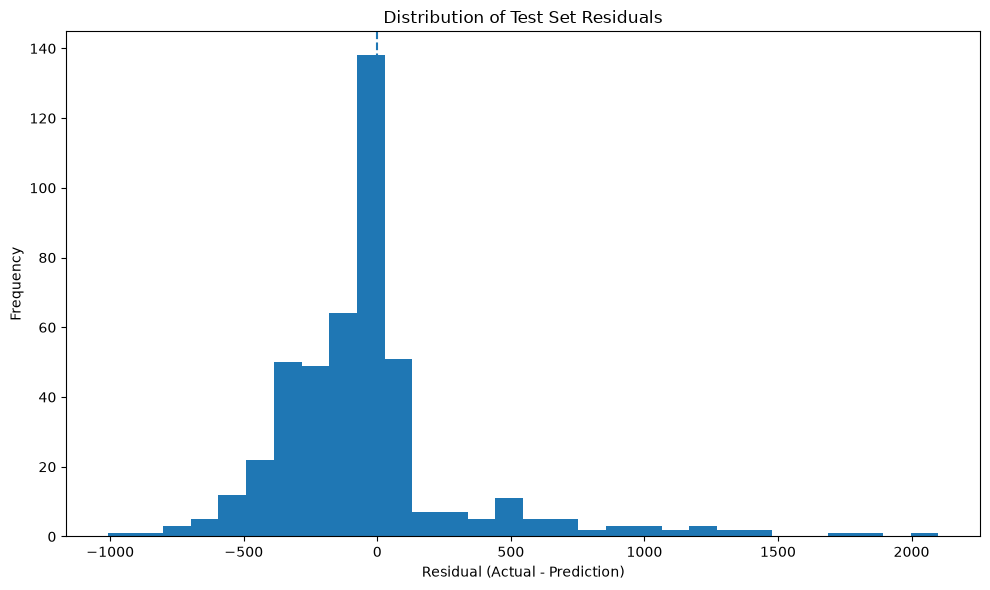

In [132]:
plt.figure(figsize=(10, 6))

plt.hist(
    test_results["Error"],
    bins=30
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Residual (Actual - Prediction)")
plt.ylabel("Frequency")
plt.title("Distribution of Test Set Residuals")

plt.tight_layout()
plt.show()

In [133]:
mean_actual_consumption = test_results["Actual"].mean()

mae_percentage = (
    final_test_mae /
    mean_actual_consumption
) * 100

print(
    "Mean actual consumption:",
    mean_actual_consumption
)

print(
    "MAE as percentage of mean consumption:",
    mae_percentage
)

Mean actual consumption: 569.6271929824561
MAE as percentage of mean consumption: 41.32083413538659


## compare three baselines

In [138]:
baseline_results = pd.DataFrame({
    "Model": [
        "Previous Hour",
        "Previous Day",
        "Hourly Profile",
        "Random Forest"
    ],
    "MAE": [
        798.6842105263158,
        249.2982456140351,
        245.95382687487955,
        235.37470760233919
    ],
    "RMSE": [
        934.3958551037605,
        465.6461272140827,
        373.5466441116492,
        373.1036554557258
    ]
})

baseline_results

,Model,MAE,RMSE
0,Previous Hour,798.684211,934.395855
1,Previous Day,249.298246,465.646127
2,Hourly Profile,245.953827,373.546644
3,Random Forest,235.374708,373.103655


In [139]:
rf_mae = baseline_results.loc[
    baseline_results["Model"] == "Random Forest",
    "MAE"
].iloc[0]

rf_rmse = baseline_results.loc[
    baseline_results["Model"] == "Random Forest",
    "RMSE"
].iloc[0]

baseline_results["MAE_Improvement_%"] = (
    (baseline_results["MAE"] - rf_mae)
    / baseline_results["MAE"]
) * 100

baseline_results["RMSE_Improvement_%"] = (
    (baseline_results["RMSE"] - rf_rmse)
    / baseline_results["RMSE"]
) * 100

baseline_results

,Model,MAE,RMSE,MAE_Improvement_%,RMSE_Improvement_%
0,Previous Hour,798.684211,934.395855,70.529691,60.070065
1,Previous Day,249.298246,465.646127,5.585093,19.873992
2,Hourly Profile,245.953827,373.546644,4.301262,0.118590
3,Random Forest,235.374708,373.103655,0.000000,0.000000


Time-of-day patterns and recent historical consumption already explain a large portion of the forecasting problem. The Random Forest adds predictive value primarily by combining recent lagged consumption, rolling statistics, and temporal information, resulting in a lower MAE than the simpler baselines. However, it provides only a marginal RMSE improvement over the hourly-profile baseline because both approaches struggle with extreme consumption spikes.

In [140]:
print("Available key variables:")

for name in [
    "engineered_df",
    "X_train",
    "X_val",
    "X_test",
    "y_train",
    "y_val",
    "y_test",
    "test_results",
    "test_forecast_origins"
]:
    print(
        name,
        "->",
        type(globals().get(name)).__name__
        if name in globals()
        else "NOT DEFINED"
    )

Available key variables:
engineered_df -> DataFrame
X_train -> DataFrame
X_val -> DataFrame
X_test -> DataFrame
y_train -> Series
y_val -> Series
y_test -> Series
test_results -> DataFrame
test_forecast_origins -> DatetimeIndex


In [141]:
print("engineered_df shape:", engineered_df.shape)

print("First timestamp:", engineered_df.index.min())
print("Last timestamp:", engineered_df.index.max())

print("Target exists:", "Appliances" in engineered_df.columns)

engineered_df shape: (3121, 37)
First timestamp: 2016-01-18 17:00:00
Last timestamp: 2016-05-27 17:00:00
Target exists: True


In [142]:
train_profile = engineered_df.loc[
    X_train.index
]

hourly_profile = (
    train_profile
    .groupby(train_profile.index.hour)["Appliances"]
    .mean()
)

print(hourly_profile)

date
0      312.417582
1      295.934066
2      286.703297
3      282.747253
4      287.032967
5      291.648352
6      328.351648
7      384.835165
8      601.648352
9      660.549451
10     755.604396
11     819.780220
12     758.901099
13     802.087912
14     689.560440
15     678.461538
16     714.285714
17     837.032967
18    1204.725275
19     904.945055
20     791.978022
21     610.989011
22     409.120879
23     340.549451
Name: Appliances, dtype: float64


In [144]:
previous_hour_test_predictions = []
previous_day_test_predictions = []
hourly_profile_test_predictions = []
baseline_test_actuals = []

for origin in test_forecast_origins:

    future_times = pd.date_range(
        start=origin + pd.Timedelta(hours=1),
        periods=24,
        freq="h"
    )

    # Actual future values
    actual_values = engineered_df.loc[
        future_times,
        "Appliances"
    ].to_numpy()

    # Previous Hour baseline
    previous_hour_value = engineered_df.loc[
        origin,
        "Appliances"
    ]

    previous_hour_forecast = np.repeat(
        previous_hour_value,
        24
    )

    # Previous Day baseline
    previous_day_forecast = engineered_df.loc[
        future_times - pd.Timedelta(hours=24),
        "Appliances"
    ].to_numpy()

    # Hourly Profile baseline
    hourly_profile_forecast = np.array([
        hourly_profile[t.hour]
        for t in future_times
    ])

    # Store
    baseline_test_actuals.extend(actual_values)
    previous_hour_test_predictions.extend(
        previous_hour_forecast
    )
    previous_day_test_predictions.extend(
        previous_day_forecast
    )
    hourly_profile_test_predictions.extend(
        hourly_profile_forecast
    )

In [145]:
baseline_test_actuals = np.array(
    baseline_test_actuals
)

previous_hour_test_predictions = np.array(
    previous_hour_test_predictions
)

previous_day_test_predictions = np.array(
    previous_day_test_predictions
)

hourly_profile_test_predictions = np.array(
    hourly_profile_test_predictions
)

print("Actuals:", baseline_test_actuals.shape)
print(
    "Previous Hour:",
    previous_hour_test_predictions.shape
)
print(
    "Previous Day:",
    previous_day_test_predictions.shape
)
print(
    "Hourly Profile:",
    hourly_profile_test_predictions.shape
)

Actuals: (456,)
Previous Hour: (456,)
Previous Day: (456,)
Hourly Profile: (456,)


In [146]:
print(
    "Baseline actuals match RF actuals:",
    np.array_equal(
        baseline_test_actuals,
        test_results["Actual"].to_numpy()
    )
)

Baseline actuals match RF actuals: True


In [147]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Previous Hour
previous_hour_test_mae = mean_absolute_error(
    baseline_test_actuals,
    previous_hour_test_predictions
)

previous_hour_test_rmse = np.sqrt(
    mean_squared_error(
        baseline_test_actuals,
        previous_hour_test_predictions
    )
)

# Previous Day
previous_day_test_mae = mean_absolute_error(
    baseline_test_actuals,
    previous_day_test_predictions
)

previous_day_test_rmse = np.sqrt(
    mean_squared_error(
        baseline_test_actuals,
        previous_day_test_predictions
    )
)

# Hourly Profile
hourly_profile_test_mae = mean_absolute_error(
    baseline_test_actuals,
    hourly_profile_test_predictions
)

hourly_profile_test_rmse = np.sqrt(
    mean_squared_error(
        baseline_test_actuals,
        hourly_profile_test_predictions
    )
)

# Random Forest
rf_test_mae = mean_absolute_error(
    test_results["Actual"],
    test_results["Prediction"]
)

rf_test_rmse = np.sqrt(
    mean_squared_error(
        test_results["Actual"],
        test_results["Prediction"]
    )
)

print(
    "Previous Hour — Test MAE:",
    previous_hour_test_mae
)
print(
    "Previous Hour — Test RMSE:",
    previous_hour_test_rmse
)

print(
    "\nPrevious Day — Test MAE:",
    previous_day_test_mae
)
print(
    "Previous Day — Test RMSE:",
    previous_day_test_rmse
)

print(
    "\nHourly Profile — Test MAE:",
    hourly_profile_test_mae
)
print(
    "Hourly Profile — Test RMSE:",
    hourly_profile_test_rmse
)

print(
    "\nRandom Forest — Test MAE:",
    rf_test_mae
)
print(
    "Random Forest — Test RMSE:",
    rf_test_rmse
)

Previous Hour — Test MAE: 251.33771929824562
Previous Hour — Test RMSE: 478.52363413007373

Previous Day — Test MAE: 268.20175438596493
Previous Day — Test RMSE: 483.9856457201576

Hourly Profile — Test MAE: 245.5800559090033
Hourly Profile — Test RMSE: 386.730591755905

Random Forest — Test MAE: 235.37470760233919
Random Forest — Test RMSE: 373.1036554557258


In [148]:
final_comparison = pd.DataFrame({
    "Model": [
        "Previous Hour",
        "Previous Day",
        "Hourly Profile",
        "Random Forest"
    ],
    "MAE": [
        previous_hour_test_mae,
        previous_day_test_mae,
        hourly_profile_test_mae,
        rf_test_mae
    ],
    "RMSE": [
        previous_hour_test_rmse,
        previous_day_test_rmse,
        hourly_profile_test_rmse,
        rf_test_rmse
    ]
})

print(final_comparison)

            Model         MAE        RMSE
0   Previous Hour  251.337719  478.523634
1    Previous Day  268.201754  483.985646
2  Hourly Profile  245.580056  386.730592
3   Random Forest  235.374708  373.103655


In [149]:
final_comparison["MAE_Improvement_%"] = (
    (
        final_comparison["MAE"]
        - rf_test_mae
    )
    / final_comparison["MAE"]
) * 100

final_comparison["RMSE_Improvement_%"] = (
    (
        final_comparison["RMSE"]
        - rf_test_rmse
    )
    / final_comparison["RMSE"]
) * 100

print(final_comparison)

            Model         MAE        RMSE  MAE_Improvement_%  \
0   Previous Hour  251.337719  478.523634           6.351220   
1    Previous Day  268.201754  483.985646          12.239684   
2  Hourly Profile  245.580056  386.730592           4.155610   
3   Random Forest  235.374708  373.103655           0.000000   

   RMSE_Improvement_%  
0           22.030255  
1           22.910182  
2            3.523625  
3            0.000000  


In [150]:
from sklearn.metrics import r2_score

rf_test_r2 = r2_score(
    test_results["Actual"],
    test_results["Prediction"]
)

print("Random Forest — Test R²:", rf_test_r2)

Random Forest — Test R²: 0.21785169589776843


The Random Forest demonstrated the best forecasting performance among the evaluated baselines, achieving a 24-hour recursive test MAE of 235.37 Wh and RMSE of 373.10 Wh. It outperformed the Previous Hour, Previous Day, and Hourly Profile baselines on both metrics. However, the relatively low R² of 0.218 and the observed underestimation of sharp consumption peaks indicate that substantial variability remains unexplained.

## Implementing XGBoost model

In [151]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

print(xgb_model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=1, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)


In [152]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

print("Features:")
print(X_train.columns.tolist())

X_train shape: (2184, 11)
y_train shape: (2184,)
X_val shape: (468, 11)
y_val shape: (468,)
Features:
['hour', 'day_of_week', 'is_weekend', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_48', 'lag_168', 'rolling_mean_3', 'rolling_mean_6']


In [153]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

xgb_val_predictions = xgb_model.predict(X_val)

xgb_one_step_mae = mean_absolute_error(
    y_val,
    xgb_val_predictions
)

xgb_one_step_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        xgb_val_predictions
    )
)

print(
    "XGBoost — One-step Validation MAE:",
    xgb_one_step_mae
)

print(
    "XGBoost — One-step Validation RMSE:",
    xgb_one_step_rmse
)

print(
    "Predictions shape:",
    xgb_val_predictions.shape
)

print(
    "Actuals shape:",
    y_val.shape
)

XGBoost — One-step Validation MAE: 191.91900634765625
XGBoost — One-step Validation RMSE: 326.111680448585
Predictions shape: (468,)
Actuals shape: (468,)


In [157]:
# Find variables related to forecast origins

origin_variables = [
    name
    for name in globals()
    if "origin" in name.lower()
]

print("Variables containing 'origin':")
print(origin_variables)

Variables containing 'origin':
['forecast_origins', 'origin', 'test_origin', 'rf_original_config', 'original_check_predictions', 'original_check_mae', 'original_check_rmse', 'test_forecast_origins']


In [158]:
for name in origin_variables:
    value = globals()[name]

    print("\nVariable:", name)
    print("Type:", type(value))

    try:
        print("Length:", len(value))
    except TypeError:
        print("Length: unavailable")


Variable: forecast_origins
Type: <class 'list'>
Length: 19

Variable: origin
Type: <class 'pandas.Timestamp'>
Length: unavailable

Variable: test_origin
Type: <class 'pandas.Timestamp'>
Length: unavailable

Variable: rf_original_config
Type: <class 'sklearn.ensemble._forest.RandomForestRegressor'>
Length: 300

Variable: original_check_predictions
Type: <class 'numpy.ndarray'>
Length: 468

Variable: original_check_mae
Type: <class 'float'>
Length: unavailable

Variable: original_check_rmse
Type: <class 'numpy.float64'>
Length: unavailable

Variable: test_forecast_origins
Type: <class 'pandas.DatetimeIndex'>
Length: 19


In [161]:
# Find existing feature/forecast-related functions and variables

forecast_related = [
    name
    for name in globals()
    if any(word in name.lower() for word in ["forecast", "feature"])
]

print("Forecast/feature-related variables:")
print(forecast_related)

Forecast/feature-related variables:
['feature_columns', 'n_forecast_windows', 'forecast_origins', 'previous_day_forecast', 'hourly_profile_forecast', 'feature_importance', 'create_recursive_features', 'recursive_24h_forecast', 'forecast', 'test_forecast_start', 'test_forecast_end', 'test_forecast_origins', 'previous_hour_forecast', 'recursive_xgb_forecast']


In [162]:
# Show the type of each relevant object

for name in forecast_related:
    value = globals()[name]

    print(
        f"{name} -> {type(value)}"
    )

feature_columns -> <class 'list'>
n_forecast_windows -> <class 'int'>
forecast_origins -> <class 'list'>
previous_day_forecast -> <class 'numpy.ndarray'>
hourly_profile_forecast -> <class 'numpy.ndarray'>
feature_importance -> <class 'pandas.Series'>
create_recursive_features -> <class 'function'>
recursive_24h_forecast -> <class 'function'>
forecast -> <class 'pandas.Series'>
test_forecast_start -> <class 'pandas.Timestamp'>
test_forecast_end -> <class 'pandas.Timestamp'>
test_forecast_origins -> <class 'pandas.DatetimeIndex'>
previous_hour_forecast -> <class 'numpy.ndarray'>
recursive_xgb_forecast -> <class 'function'>


In [165]:
def recursive_xgb_forecast(model, history, start_timestamp, horizon=24):

    history = history.copy()

    predictions = []

    current_timestamp = start_timestamp

    for step in range(horizon):

        next_timestamp = (
            current_timestamp
            + pd.Timedelta(hours=1)
        )

        feature_row = create_recursive_features(
            history,
            next_timestamp
        )

        prediction = model.predict(
            feature_row
        )[0]

        predictions.append(prediction)

        history.loc[
            next_timestamp,
            "Appliances"
        ] = prediction

        current_timestamp = next_timestamp

    return predictions

In [166]:
xgb_recursive_predictions = []
xgb_recursive_actuals = []

history_data = engineered_df[["Appliances"]].copy()

for origin in forecast_origins:

    history = history_data.loc[:origin]

    predictions = recursive_xgb_forecast(
        xgb_model,
        history,
        origin,
        horizon=24
    )

    actual_times = pd.date_range(
        start=origin + pd.Timedelta(hours=1),
        periods=24,
        freq="h"
    )

    actual_values = engineered_df.loc[
        actual_times,
        "Appliances"
    ].tolist()

    xgb_recursive_predictions.extend(predictions)
    xgb_recursive_actuals.extend(actual_values)

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:lag_1: object, lag_2: object, lag_3: object, lag_24: object, lag_48: object, lag_168: object, rolling_mean_3: object, rolling_mean_6: object

In [167]:
# Test the existing recursive feature function

test_origin = forecast_origins[0]

test_history = engineered_df[["Appliances"]].loc[:test_origin].copy()

test_timestamp = test_origin + pd.Timedelta(hours=1)

test_features = create_recursive_features(
    test_history,
    test_timestamp
)

print("Feature values:")
print(test_features)

print("\nFeature dtypes:")
print(test_features.dtypes)

print("\nFeature columns:")
print(test_features.columns.tolist())

Feature values:
                     hour  day_of_week  is_weekend  \
2016-04-18 18:00:00    18            0           0   

                                                                 lag_1  \
2016-04-18 18:00:00  Appliances    1580
Name: 2016-04-18 17:00:00, ...   

                                                                 lag_2  \
2016-04-18 18:00:00  Appliances    420
Name: 2016-04-18 16:00:00, d...   

                                                                 lag_3  \
2016-04-18 18:00:00  Appliances    330
Name: 2016-04-18 15:00:00, d...   

                                                                lag_24  \
2016-04-18 18:00:00  Appliances    730
Name: 2016-04-17 18:00:00, d...   

                                                                lag_48  \
2016-04-18 18:00:00  Appliances    820
Name: 2016-04-16 18:00:00, d...   

                                                               lag_168  \
2016-04-18 18:00:00  Appliances    600
Name: 2016-04-11 

In [168]:
print("\nXGBoost training dtypes:")
print(X_train.dtypes)


XGBoost training dtypes:
hour                int64
day_of_week         int64
is_weekend          int64
lag_1             float64
lag_2             float64
lag_3             float64
lag_24            float64
lag_48            float64
lag_168           float64
rolling_mean_3    float64
rolling_mean_6    float64
dtype: object


In [169]:
test_origin = forecast_origins[0]

test_history = engineered_df[["Appliances"]].loc[:test_origin].copy()

test_timestamp = test_origin + pd.Timedelta(hours=1)

test_features = create_recursive_features(
    test_history,
    test_timestamp
)

print("Generated feature row:")
print(test_features)

print("\nGenerated feature dtypes:")
print(test_features.dtypes)

Generated feature row:
                     hour  day_of_week  is_weekend  \
2016-04-18 18:00:00    18            0           0   

                                                                 lag_1  \
2016-04-18 18:00:00  Appliances    1580
Name: 2016-04-18 17:00:00, ...   

                                                                 lag_2  \
2016-04-18 18:00:00  Appliances    420
Name: 2016-04-18 16:00:00, d...   

                                                                 lag_3  \
2016-04-18 18:00:00  Appliances    330
Name: 2016-04-18 15:00:00, d...   

                                                                lag_24  \
2016-04-18 18:00:00  Appliances    730
Name: 2016-04-17 18:00:00, d...   

                                                                lag_48  \
2016-04-18 18:00:00  Appliances    820
Name: 2016-04-16 18:00:00, d...   

                                                               lag_168  \
2016-04-18 18:00:00  Appliances    600
Name: 2016

In [170]:
def create_recursive_features(history, timestamp):

    values = history["Appliances"]

    features_row = {
        "hour": int(timestamp.hour),
        "day_of_week": int(timestamp.dayofweek),
        "is_weekend": int(timestamp.dayofweek >= 5),

        "lag_1": float(values.iloc[-1]),
        "lag_2": float(values.iloc[-2]),
        "lag_3": float(values.iloc[-3]),

        "lag_24": float(values.iloc[-24]),
        "lag_48": float(values.iloc[-48]),
        "lag_168": float(values.iloc[-168]),

        "rolling_mean_3": float(values.iloc[-3:].mean()),
        "rolling_mean_6": float(values.iloc[-6:].mean())
    }

    return pd.DataFrame(
        [features_row],
        index=[timestamp]
    )[feature_columns]

In [171]:
test_origin = forecast_origins[0]

test_history = engineered_df[
    ["Appliances"]
].loc[:test_origin].copy()

test_timestamp = (
    test_origin + pd.Timedelta(hours=1)
)

test_features = create_recursive_features(
    test_history,
    test_timestamp
)

print("Generated feature row:")
print(test_features)

print("\nGenerated feature dtypes:")
print(test_features.dtypes)

Generated feature row:
                     hour  day_of_week  is_weekend   lag_1  lag_2  lag_3  \
2016-04-18 18:00:00    18            0           0  1580.0  420.0  330.0   

                     lag_24  lag_48  lag_168  rolling_mean_3  rolling_mean_6  
2016-04-18 18:00:00   730.0   820.0    600.0      776.666667           530.0  

Generated feature dtypes:
hour                int64
day_of_week         int64
is_weekend          int64
lag_1             float64
lag_2             float64
lag_3             float64
lag_24            float64
lag_48            float64
lag_168           float64
rolling_mean_3    float64
rolling_mean_6    float64
dtype: object


In [172]:
#validation 
xgb_recursive_predictions = []
xgb_recursive_actuals = []

history_data = engineered_df[["Appliances"]].copy()

for origin in forecast_origins:

    history = history_data.loc[:origin].copy()

    predictions = recursive_xgb_forecast(
        xgb_model,
        history,
        origin,
        horizon=24
    )

    actual_times = pd.date_range(
        start=origin + pd.Timedelta(hours=1),
        periods=24,
        freq="h"
    )

    actual_values = engineered_df.loc[
        actual_times,
        "Appliances"
    ].tolist()

    xgb_recursive_predictions.extend(predictions)
    xgb_recursive_actuals.extend(actual_values)

In [173]:
xgb_recursive_predictions = np.array(
    xgb_recursive_predictions
)

xgb_recursive_actuals = np.array(
    xgb_recursive_actuals
)

print(
    "Predictions shape:",
    xgb_recursive_predictions.shape
)

print(
    "Actuals shape:",
    xgb_recursive_actuals.shape
)

xgb_recursive_mae = mean_absolute_error(
    xgb_recursive_actuals,
    xgb_recursive_predictions
)

xgb_recursive_rmse = np.sqrt(
    mean_squared_error(
        xgb_recursive_actuals,
        xgb_recursive_predictions
    )
)

print(
    "XGBoost — 24H Recursive Validation MAE:",
    xgb_recursive_mae
)

print(
    "XGBoost — 24H Recursive Validation RMSE:",
    xgb_recursive_rmse
)

Predictions shape: (456,)
Actuals shape: (456,)
XGBoost — 24H Recursive Validation MAE: 253.5704803466797
XGBoost — 24H Recursive Validation RMSE: 378.87840232718463


In [174]:
print(xgb_model)
print("\nXGBoost parameters:")
print(xgb_model.get_params())

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=1, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)

XGBoost parameters:
{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': Tru

In [175]:
xgb_tuned_model = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    n_jobs=-1,
    random_state=42
)

xgb_tuned_model.fit(
    X_train,
    y_train
)

print(xgb_tuned_model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)


In [176]:
xgb_tuned_val_predictions = xgb_tuned_model.predict(
    X_val
)

xgb_tuned_val_mae = mean_absolute_error(
    y_val,
    xgb_tuned_val_predictions
)

xgb_tuned_val_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        xgb_tuned_val_predictions
    )
)

print(
    "Tuned XGBoost — One-step Validation MAE:",
    xgb_tuned_val_mae
)

print(
    "Tuned XGBoost — One-step Validation RMSE:",
    xgb_tuned_val_rmse
)

Tuned XGBoost — One-step Validation MAE: 197.65216064453125
Tuned XGBoost — One-step Validation RMSE: 329.0629807688796


In [177]:
xgb_tuned_recursive_predictions = []
xgb_tuned_recursive_actuals = []

history_data = engineered_df[["Appliances"]].copy()

for origin in forecast_origins:

    history = history_data.loc[:origin].copy()

    predictions = recursive_xgb_forecast(
        xgb_tuned_model,
        history,
        origin,
        horizon=24
    )

    actual_times = pd.date_range(
        start=origin + pd.Timedelta(hours=1),
        periods=24,
        freq="h"
    )

    actual_values = engineered_df.loc[
        actual_times,
        "Appliances"
    ].tolist()

    xgb_tuned_recursive_predictions.extend(
        predictions
    )

    xgb_tuned_recursive_actuals.extend(
        actual_values
    )

In [178]:
xgb_tuned_recursive_predictions = np.array(
    xgb_tuned_recursive_predictions
)

xgb_tuned_recursive_actuals = np.array(
    xgb_tuned_recursive_actuals
)

xgb_tuned_recursive_mae = mean_absolute_error(
    xgb_tuned_recursive_actuals,
    xgb_tuned_recursive_predictions
)

xgb_tuned_recursive_rmse = np.sqrt(
    mean_squared_error(
        xgb_tuned_recursive_actuals,
        xgb_tuned_recursive_predictions
    )
)

print(
    "Predictions shape:",
    xgb_tuned_recursive_predictions.shape
)

print(
    "Actuals shape:",
    xgb_tuned_recursive_actuals.shape
)

print(
    "Tuned XGBoost — 24H Recursive Validation MAE:",
    xgb_tuned_recursive_mae
)

print(
    "Tuned XGBoost — 24H Recursive Validation RMSE:",
    xgb_tuned_recursive_rmse
)

Predictions shape: (456,)
Actuals shape: (456,)
Tuned XGBoost — 24H Recursive Validation MAE: 272.9077453613281
Tuned XGBoost — 24H Recursive Validation RMSE: 387.6970466743331


XGBoost on test data

In [179]:
print("Number of test forecast origins:", len(test_forecast_origins))
print("First origin:", test_forecast_origins[0])
print("Last origin:", test_forecast_origins[-1])

Number of test forecast origins: 19
First origin: 2016-05-08 05:00:00
Last origin: 2016-05-26 05:00:00


In [180]:
xgb_test_predictions = []
xgb_test_actuals = []

history_data = engineered_df[["Appliances"]].copy()

for origin in test_forecast_origins:

    history = history_data.loc[:origin].copy()

    predictions = recursive_xgb_forecast(
        xgb_model,
        history,
        origin,
        horizon=24
    )

    actual_times = pd.date_range(
        start=origin + pd.Timedelta(hours=1),
        periods=24,
        freq="h"
    )

    actual_values = engineered_df.loc[
        actual_times,
        "Appliances"
    ].tolist()

    xgb_test_predictions.extend(predictions)
    xgb_test_actuals.extend(actual_values)

In [181]:
xgb_test_predictions = np.array(
    xgb_test_predictions
)

xgb_test_actuals = np.array(
    xgb_test_actuals
)

print(
    "Predictions shape:",
    xgb_test_predictions.shape
)

print(
    "Actuals shape:",
    xgb_test_actuals.shape
)

xgb_test_mae = mean_absolute_error(
    xgb_test_actuals,
    xgb_test_predictions
)

xgb_test_rmse = np.sqrt(
    mean_squared_error(
        xgb_test_actuals,
        xgb_test_predictions
    )
)

print(
    "XGBoost — Final Test 24H Recursive MAE:",
    xgb_test_mae
)

print(
    "XGBoost — Final Test 24H Recursive RMSE:",
    xgb_test_rmse
)

Predictions shape: (456,)
Actuals shape: (456,)
XGBoost — Final Test 24H Recursive MAE: 250.30569458007812
XGBoost — Final Test 24H Recursive RMSE: 404.79265525698463


In [182]:
xgb_test_r2 = r2_score(
    xgb_test_actuals,
    xgb_test_predictions
)

print(
    "XGBoost — Final Test R²:",
    xgb_test_r2
)

XGBoost — Final Test R²: 0.07934838533401489


In [184]:
# ==================================================
# FINAL MODEL COMPARISON
# ==================================================

final_model_comparison = pd.DataFrame({
    "Model": [
        "Previous Hour",
        "Previous Day",
        "Hourly Profile",
        "Random Forest",
        "XGBoost"
    ],
    
    "MAE": [
        251.33771929824562,
        268.20175438596493,
        245.5800559090033,
        235.37470760233919,
        250.30569458007812
    ],
    
    "RMSE": [
        478.52363413007373,
        483.9856457201576,
        386.730591755905,
        373.1036554557258,
        404.79265525698463
    ],
    
    "R²": [
        np.nan,
        np.nan,
        np.nan,
        0.21785169589776843,
        0.07934838533401489
    ]
})

# Calculate MAE difference relative to Random Forest
rf_mae = 235.37470760233919

final_model_comparison["MAE Difference vs RF (%)"] = (
    (final_model_comparison["MAE"] - rf_mae)
    / rf_mae
    * 100
)

# Round for presentation
final_model_comparison_display = (
    final_model_comparison.copy()
)

final_model_comparison_display[
    ["MAE", "RMSE", "R²", "MAE Difference vs RF (%)"]
] = (
    final_model_comparison_display[
        ["MAE", "RMSE", "R²", "MAE Difference vs RF (%)"]
    ].round(2)
)

final_model_comparison_display

,Model,MAE,RMSE,R²,MAE Difference vs RF (%)
0,Previous Hour,251.34,478.52,NaN,6.78
1,Previous Day,268.20,483.99,NaN,13.95
2,Hourly Profile,245.58,386.73,NaN,4.34
3,Random Forest,235.37,373.10,0.22,0.00
4,XGBoost,250.31,404.79,0.08,6.34


## Final Model Comparison and Selection

The forecasting models were evaluated using the same unseen test period and a
24-hour recursive forecasting strategy. Three baseline approaches were
compared with two machine learning models: Random Forest and XGBoost.

The **Random Forest model achieved the best overall performance**, obtaining
the lowest MAE and RMSE among all evaluated models. It also achieved the
highest R² among the machine learning models.

The baseline models provided useful reference points. The Hourly Profile
baseline performed better than the Previous Hour and Previous Day baselines,
but it was still outperformed by Random Forest.

XGBoost was also evaluated using the same 24-hour recursive forecasting
procedure. Although XGBoost achieved competitive results, its final test
performance was weaker than Random Forest across all three metrics. Random
Forest achieved a lower MAE and RMSE and a substantially higher R².

Therefore, **Random Forest was selected as the final forecasting model** for
the energy consumption forecasting system. The selection was based on its
consistent superiority during both validation and final test evaluation,
rather than selecting a model based only on one-step prediction performance.

It is important to note that the final Random Forest R² of approximately 0.218
indicates that the model explains a limited proportion of the variation in
the test observations. Therefore, the model should not be described as highly
accurate. Nevertheless, it provides the best forecasting performance among
the evaluated approaches and improves upon all tested baseline methods.